In [43]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled.")

PyTorch version: 2.10.0+cpu
CUDA available: False


In [74]:
import os
import random
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

OpenCV: 4.13.0
NumPy: 2.0.2
Pandas: 2.3.3


In [73]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 7
EPOCHS = 10

CLASS_NAMES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "sad",
    "surprise",
    "neutral"
]

print("Device:", DEVICE)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASS_NAMES)

Device: cpu
Image size: 224
Batch size: 64
Classes: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']


In [46]:
#INPUT_DIR = Path("/kaggle/input")

#print("Kaggle input files:")
#print()

#for path in INPUT_DIR.rglob("*"):
 #   if path.is_file():
  #      print(path)

DATASET_DIR = Path(
    "/kaggle/input/datasets/msambare/fer2013"
)

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

print("\nTrain classes:")

for class_dir in sorted(TRAIN_DIR.iterdir()):
    if class_dir.is_dir():
        print(class_dir.name)

print("\nTest classes:")

for class_dir in sorted(TEST_DIR.iterdir()):
    if class_dir.is_dir():
        print(class_dir.name)

Train directory: /kaggle/input/datasets/msambare/fer2013/train
Test directory: /kaggle/input/datasets/msambare/fer2013/test

Train classes:
angry
disgust
fear
happy
neutral
sad
surprise

Test classes:
angry
disgust
fear
happy
neutral
sad
surprise


In [47]:
def count_images(directory):
    counts = {}

    for class_dir in sorted(directory.iterdir()):

        if class_dir.is_dir():

            count = len(
                list(class_dir.glob("*.jpg"))
            )

            counts[class_dir.name] = count

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training images:")
for emotion, count in train_counts.items():
    print(f"{emotion:10s}: {count}")

print("\nTest images:")
for emotion, count in test_counts.items():
    print(f"{emotion:10s}: {count}")

print("\nTotal training:",
      sum(train_counts.values()))

print("Total test:",
      sum(test_counts.values()))

Training images:
angry     : 3995
disgust   : 436
fear      : 4097
happy     : 7215
neutral   : 4965
sad       : 4830
surprise  : 3171

Test images:
angry     : 958
disgust   : 111
fear      : 1024
happy     : 1774
neutral   : 1233
sad       : 1247
surprise  : 831

Total training: 28709
Total test: 7178


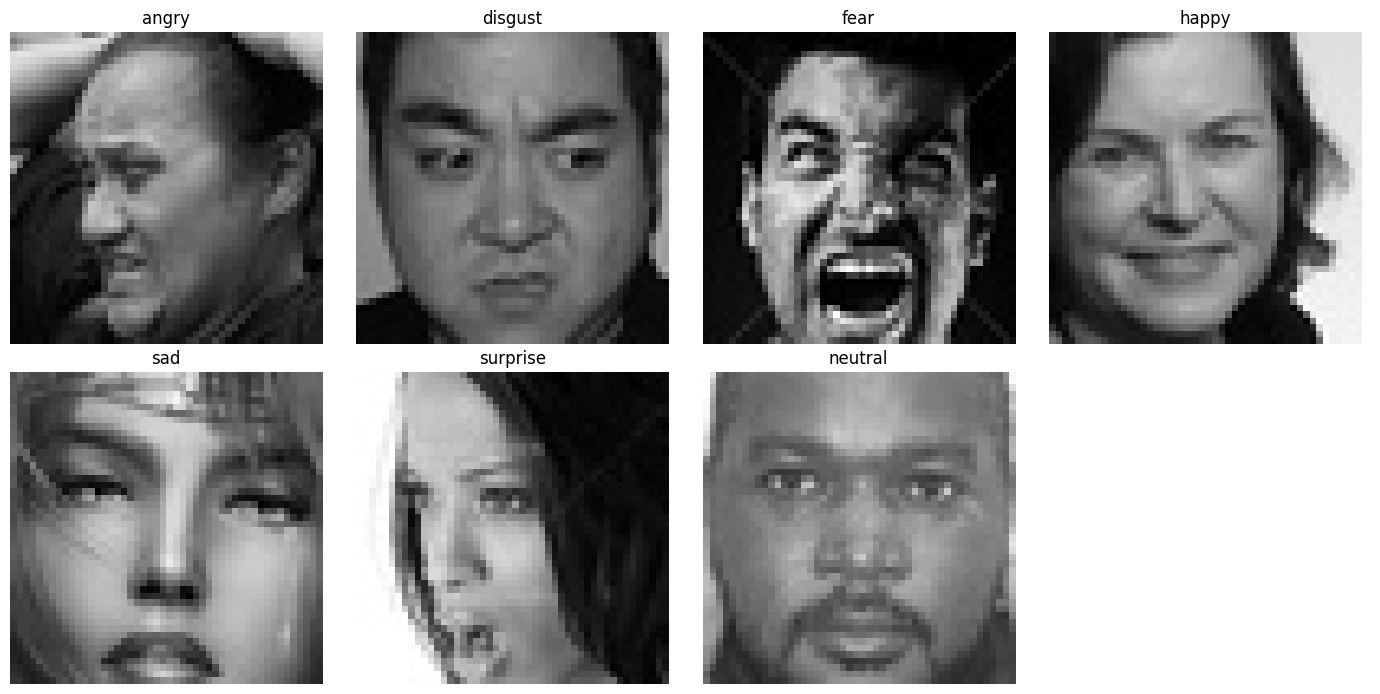

In [48]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)

axes = axes.flatten()

for i, emotion in enumerate(CLASS_NAMES):

    emotion_dir = TRAIN_DIR / emotion

    image_files = list(
        emotion_dir.glob("*.jpg")
    )

    image_path = random.choice(
        image_files
    )

    image = cv2.imread(
        str(image_path)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(image)

    axes[i].set_title(
        emotion
    )

    axes[i].axis("off")


# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

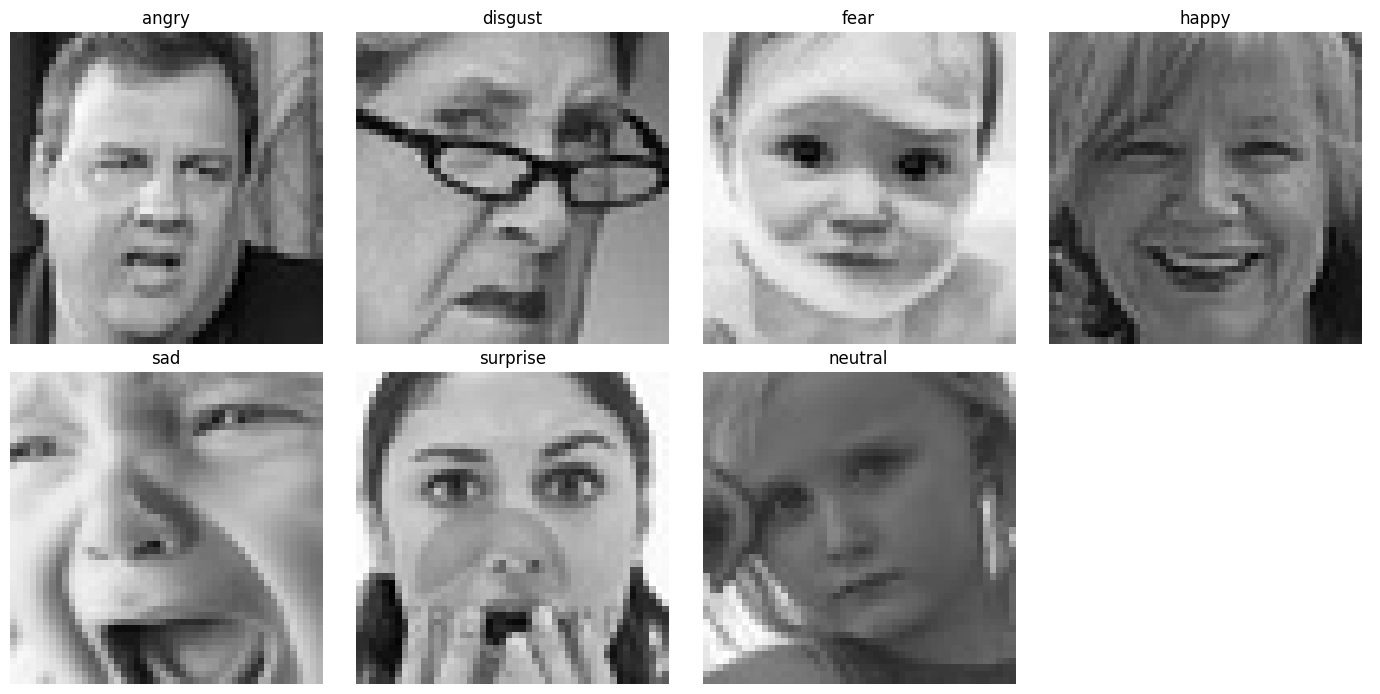

In [49]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)

axes = axes.flatten()

for i, emotion in enumerate(CLASS_NAMES):

    emotion_dir = TRAIN_DIR / emotion

    image_files = list(
        emotion_dir.glob("*.jpg")
    )

    image_path = random.choice(
        image_files
    )

    image = cv2.imread(
        str(image_path)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(image)

    axes[i].set_title(
        emotion
    )

    axes[i].axis("off")


# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [50]:
sample_files = list(
    (TRAIN_DIR / "happy").glob("*.jpg")
)

sample_path = sample_files[0]

image = cv2.imread(
    str(sample_path)
)

print("Image path:", sample_path)
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Min pixel:", image.min())
print("Max pixel:", image.max())

Image path: /kaggle/input/datasets/msambare/fer2013/train/happy/Training_65647822.jpg
Image shape: (48, 48, 3)
Image dtype: uint8
Min pixel: 54
Max pixel: 215


In [51]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

In [52]:
train_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


test_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [53]:
train_dataset = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=str(TEST_DIR),
    transform=test_transform
)

print("Classes:", train_dataset.classes)

print(
    "Class mapping:",
    train_dataset.class_to_idx
)

print(
    "Training images:",
    len(train_dataset)
)

print(
    "Test images:",
    len(test_dataset)
)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Training images: 28709
Test images: 7178


In [54]:
from torch.utils.data import random_split

validation_ratio = 0.10

validation_size = int(
    len(train_dataset) * validation_ratio
)

training_size = (
    len(train_dataset)
    - validation_size
)

train_subset, val_subset = random_split(
    train_dataset,
    [
        training_size,
        validation_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training:", len(train_subset))
print("Validation:", len(val_subset))
print("Test:", len(test_dataset))

Training: 25839
Validation: 2870
Test: 7178


In [55]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 404
Validation batches: 45
Test batches: 113


In [56]:
images, labels = next(
    iter(train_loader)
)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

print(
    "Labels:",
    labels[:10]
)

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
Labels: tensor([5, 2, 5, 6, 5, 3, 2, 6, 0, 3])


In [57]:
from torchvision.models import efficientnet_b0
from torch import nn

model = efficientnet_b0(
    weights=None
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print("EfficientNet-B0 created successfully.")
print("Device:", DEVICE)
print(model.classifier)

EfficientNet-B0 created successfully.
Device: cpu
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)


In [58]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = []

for _, label in train_subset:
    train_labels.append(label)

train_labels = np.array(
    train_labels
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print(
    "Class weights:",
    class_weights
)

Class weights: tensor([1.0200, 9.4165, 1.0050, 0.5693, 0.8286, 0.8474, 1.2907])


In [59]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [60]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [61]:
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    loss = running_loss / total
    accuracy = correct / total

    return (
        loss,
        accuracy,
        all_labels,
        all_predictions
    )

In [ ]:
EPOCHS = 10 # 1 for testing other wise 10 

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

MODEL_PATH = (
    "/kaggle/working/"
    "openemotion_efficientnet_b0.pth"
)

for epoch in range(EPOCHS):

    train_loss, train_accuracy = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )
    )

    (
        val_loss,
        val_accuracy,
        _,
        _
    ) = evaluate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(
        val_accuracy
    )

    history[
        "train_loss"
    ].append(train_loss)

    history[
        "train_accuracy"
    ].append(train_accuracy)

    history[
        "val_loss"
    ].append(val_loss)

    history[
        "val_accuracy"
    ].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print(
            "  ✓ Best model saved"
        )

print(
    "\nBest validation accuracy:",
    best_val_accuracy
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/1 | Train Loss: 1.9451 | Train Acc: 0.1856 | Val Loss: 1.9278 | Val Acc: 0.2007
  ✓ Best model saved

Best validation accuracy: 0.20069686411149826


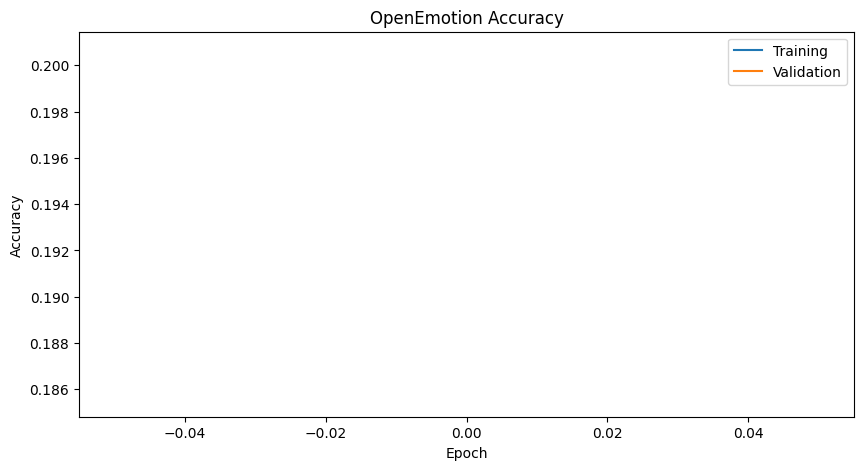

In [63]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_accuracy"],
    label="Training"
)

plt.plot(
    history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "OpenEmotion Accuracy"
)

plt.legend()

plt.show()

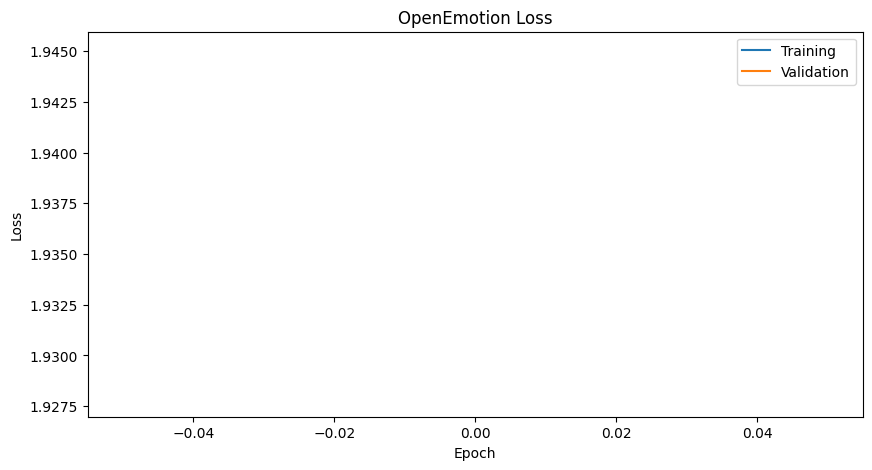

In [65]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Training"
)

plt.plot(
    history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "OpenEmotion Loss"
)

plt.legend()

plt.show()

In [66]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print(
    "Best OpenEmotion model loaded."
)

Best OpenEmotion model loaded.


In [67]:
(
    test_loss,
    test_accuracy,
    test_labels,
    test_predictions
) = evaluate(
    model,
    test_loader,
    criterion
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

Test Loss: 1.8909
Test Accuracy: 0.2301


In [75]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=train_dataset.classes,
        digits=4
    )
)

              precision    recall  f1-score   support

       angry     0.1389    0.0104    0.0194       958
     disgust     0.0000    0.0000    0.0000       111
        fear     0.1860    0.0312    0.0535      1024
       happy     0.2757    0.2570    0.2660      1774
     neutral     0.1964    0.4201    0.2677      1233
         sad     0.2514    0.2526    0.2520      1247
    surprise     0.2329    0.3863    0.2906       831

    accuracy                         0.2301      7178
   macro avg     0.1831    0.1940    0.1642      7178
weighted avg     0.2176    0.2301    0.1994      7178



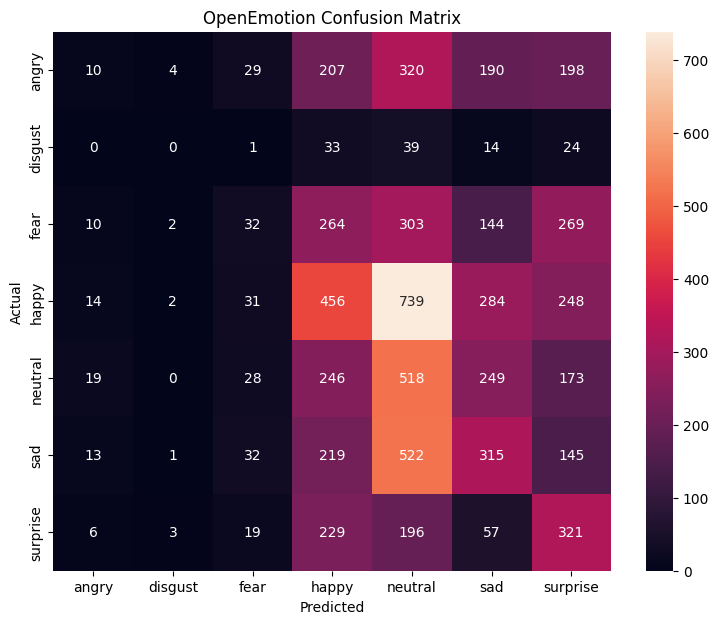

In [76]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "OpenEmotion Confusion Matrix"
)

plt.show()

In [77]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

if face_detector.empty():
    raise RuntimeError(
        "Could not load OpenCV face detector."
    )

print(
    "OpenCV face detector loaded."
)

OpenCV face detector loaded.


In [80]:
def predict_emotion(face_bgr):

    face_rgb = cv2.cvtColor(
        face_bgr,
        cv2.COLOR_BGR2RGB
    )

    transform = test_transform

    tensor = transform(
        face_rgb
    )

    tensor = tensor.unsqueeze(
        0
    ).to(DEVICE)

    with torch.no_grad():

        outputs = model(
            tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = (
            probabilities.max(dim=1)
        )

    emotion = train_dataset.classes[
        prediction.item()
    ]

    return (
        emotion,
        confidence.item()
    )

In [81]:
def detect_emotions(
    image_path
):

    image = cv2.imread(
        image_path
    )

    if image is None:

        raise ValueError(
            f"Could not read: {image_path}"
        )

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40)
    )

    results = []

    for x, y, w, h in faces:

        face = image[
            y:y+h,
            x:x+w
        ]

        emotion, confidence = (
            predict_emotion(face)
        )

        label = (
            f"{emotion} "
            f"{confidence * 100:.1f}%"
        )

        cv2.rectangle(
            image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image,
            label,
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

        results.append({
            "box": [x, y, w, h],
            "emotion": emotion,
            "confidence": confidence
        })

    return image, results

In [84]:
metadata = {
    "project": "OpenEmotion",
    "version": "0.1.0",
    "model": "EfficientNet-B0",
    "dataset": "FER-2013",
    "image_size": IMG_SIZE,
    "classes": train_dataset.classes,
    "framework": "PyTorch",
    "opencv_version": cv2.__version__
}

METADATA_PATH = (
    "/kaggle/working/"
    "openemotion_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    "Metadata saved:",
    METADATA_PATH
)

Metadata saved: /kaggle/working/openemotion_metadata.json


In [85]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

In [86]:
MODEL_PATH = "/kaggle/working/openemotion_efficientnet_b0.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)


Model saved to:
/kaggle/working/openemotion_efficientnet_b0.pth
